# UK House Price Predictor
## Phase 1: Data Loading & Exploration

**Dataset:** UK Land Registry Price Paid Data  
**Source:** https://www.gov.uk/government/collections/price-paid-data  
**Goal:** Understand the data structure, clean it, and visualise key patterns.

## 1. Import Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

print('Libraries loaded successfully')

Libraries loaded successfully


## 2. Load Dataset

The Land Registry file has no headers — we add them manually.

**How to download the file:**
1. Go to: https://www.gov.uk/government/collections/price-paid-data
2. Download the annual file: `pp-2025.csv`
3. Place it in the same folder as this notebook

In [2]:
columns = [
    'transaction_id',  # Unique transaction ID
    'price',           # Sale price (£)
    'date',            # Transfer date
    'postcode',        # Postcode
    'property_type',   # D=Detached, S=Semi, T=Terraced, F=Flat, O=Other
    'new_build',       # Y=New build, N=Existing
    'tenure',          # F=Freehold, L=Leasehold
    'paon',            # House number / name
    'saon',            # Flat / unit (if applicable)
    'street',          # Street
    'locality',        # Locality
    'town',            # Town
    'district',        # District
    'county',          # County
    'ppd_category',    # A=Standard, B=Other
    'record_status'    # A=Added, C=Changed, D=Deleted
]

# Update filename if needed
df = pd.read_csv('pp-2025.csv', header=None, names=columns, low_memory=False)

print(f'Dataset loaded: {len(df):,} transactions')
print(f'Columns: {list(df.columns)}')

Dataset loaded: 879,386 transactions
Columns: ['transaction_id', 'price', 'date', 'postcode', 'property_type', 'new_build', 'tenure', 'paon', 'saon', 'street', 'locality', 'town', 'district', 'county', 'ppd_category', 'record_status']


## 3. First Look

In [3]:
df.head()

,transaction_id,price,date,postcode,property_type,new_build,tenure,paon,saon,street,locality,town,district,county,ppd_category,record_status
0,{3DCCB7C9-94EA-5B9D-E063-4704A8C0331E},451225,2025-07-31 00:00,N15 4AB,F,N,L,288,NaN,PHILIP LANE,NaN,LONDON,HARINGEY,GREATER LONDON,A,A
1,{3DCCB7C9-94EB-5B9D-E063-4704A8C0331E},485000,2025-01-20 00:00,N4 4NR,F,N,L,CONNAUGHT LODGE,FLAT 19,CONNAUGHT ROAD,NaN,LONDON,HARINGEY,GREATER LONDON,A,A
2,{3DCCB7C9-94ED-5B9D-E063-4704A8C0331E},380000,2025-03-20 00:00,N21 3AN,T,N,L,41A,NaN,FERNLEIGH ROAD,NaN,LONDON,ENFIELD,GREATER LONDON,A,A
3,{3DCCB7C9-94EE-5B9D-E063-4704A8C0331E},730000,2025-03-27 00:00,EN5 3LT,S,N,F,3,NaN,HAYDEN CLOSE,NaN,BARNET,BARNET,GREATER LONDON,A,A
4,{3DCCB7C9-94F0-5B9D-E063-4704A8C0331E},325000,2025-03-28 00:00,EN5 1HY,F,N,L,"LANDER COURT, 48",2,LYONSDOWN ROAD,NEW BARNET,BARNET,BARNET,GREATER LONDON,A,A


In [ ]:
df.info()

In [4]:
print('=== PRICE STATISTICS ===')
print(f"Mean:   £{df['price'].mean():,.0f}")
print(f"Median: £{df['price'].median():,.0f}")
print(f"Min:    £{df['price'].min():,.0f}")
print(f"Max:    £{df['price'].max():,.0f}")
print(f"Std:    £{df['price'].std():,.0f}")

=== PRICE STATISTICS ===
Mean:   £383,655
Median: £285,000
Min:    £1
Max:    £793,020,000
Std:    £1,241,467


## 4. Data Cleaning

In [5]:
print('=== MISSING VALUES ===')
missing = df.isnull().sum()
print(missing[missing > 0])

=== MISSING VALUES ===
postcode      1900
saon        776963
street       14057
locality    543513
dtype: int64


In [6]:
# Parse dates and extract time features
df['date'] = pd.to_datetime(df['date'])
df['month'] = df['date'].dt.month
df['quarter'] = df['date'].dt.quarter

# Remove outliers (prices below £10k or above £10M)
n_before = len(df)
df = df[(df['price'] >= 10_000) & (df['price'] <= 10_000_000)]

# Keep only standard transactions (category A)
df = df[df['ppd_category'] == 'A']

print(f'Rows removed as outliers: {n_before - len(df):,}')
print(f'Clean dataset: {len(df):,} transactions')

Rows removed as outliers: 139,951
Clean dataset: 739,435 transactions


## 5. Visualisations

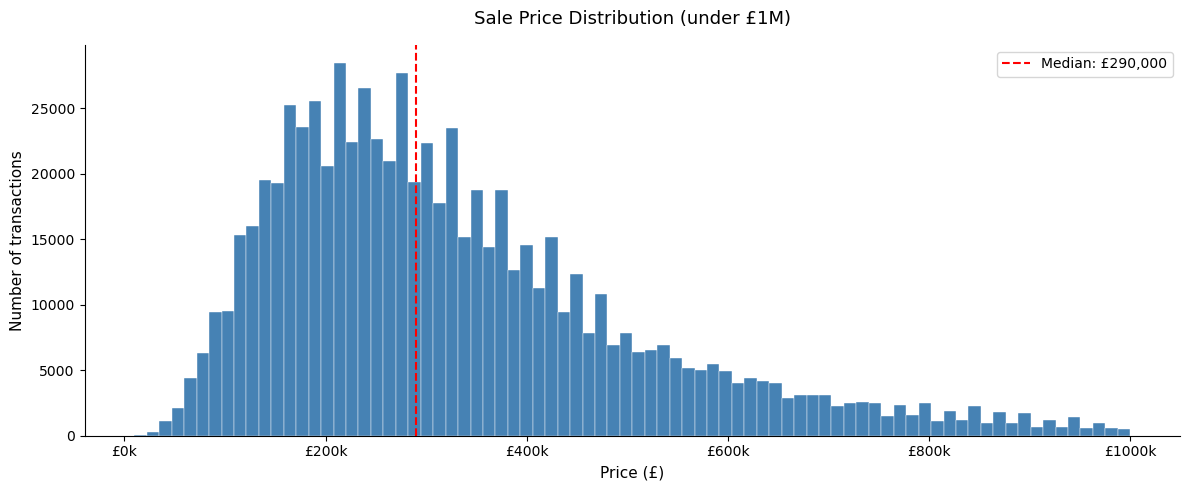

In [7]:
# Chart 1: Price distribution
fig, ax = plt.subplots()
prices = df[df['price'] < 1_000_000]['price']
ax.hist(prices, bins=80, color='steelblue', edgecolor='white', linewidth=0.3)
ax.axvline(prices.median(), color='red', linestyle='--', linewidth=1.5,
           label=f"Median: £{prices.median():,.0f}")
ax.set_title('Sale Price Distribution (under £1M)', fontsize=13, pad=15)
ax.set_xlabel('Price (£)', fontsize=11)
ax.set_ylabel('Number of transactions', fontsize=11)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x/1000:.0f}k'))
ax.legend()
plt.tight_layout()
plt.savefig('chart1_price_distribution.png', dpi=150)
plt.show()

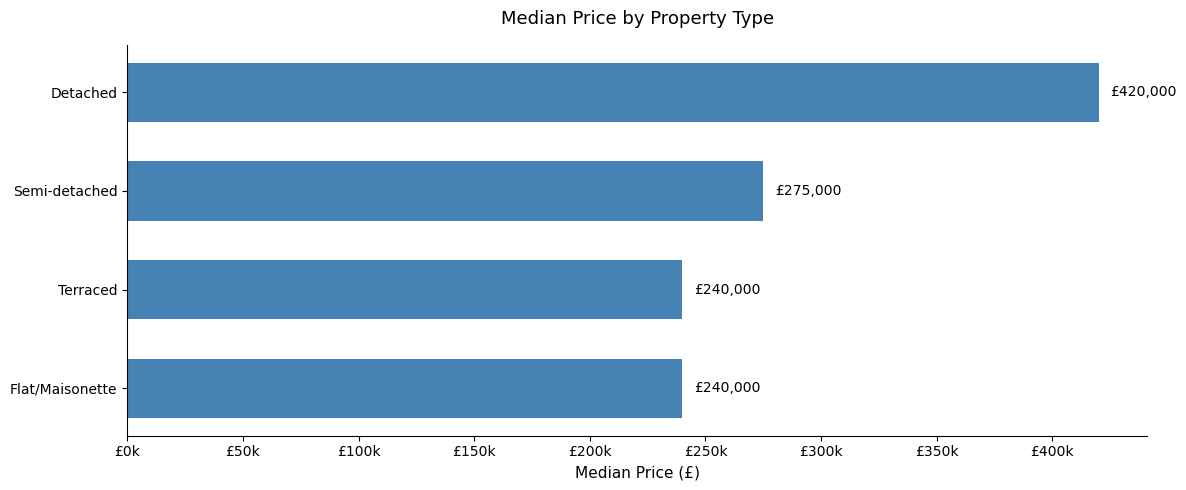

In [8]:
# Chart 2: Median price by property type
type_map = {'D':'Detached','S':'Semi-detached','T':'Terraced','F':'Flat/Maisonette','O':'Other'}
df['property_label'] = df['property_type'].map(type_map)
median_type = df.groupby('property_label')['price'].median().sort_values(ascending=True)

fig, ax = plt.subplots()
bars = ax.barh(median_type.index, median_type.values, color='steelblue', height=0.6)
for bar, val in zip(bars, median_type.values):
    ax.text(val + 5000, bar.get_y() + bar.get_height()/2,
            f'£{val:,.0f}', va='center', fontsize=10)
ax.set_title('Median Price by Property Type', fontsize=13, pad=15)
ax.set_xlabel('Median Price (£)', fontsize=11)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x/1000:.0f}k'))
plt.tight_layout()
plt.savefig('chart2_property_type.png', dpi=150)
plt.show()

In [ ]:
# Chart 3: Transactions by month
tx_month = df.groupby('month').size()
month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

fig, ax = plt.subplots()
ax.plot(range(1, len(tx_month)+1), tx_month.values,
        marker='o', color='steelblue', linewidth=2, markersize=6)
ax.fill_between(range(1, len(tx_month)+1), tx_month.values, alpha=0.1, color='steelblue')
ax.set_xticks(range(1, len(tx_month)+1))
ax.set_xticklabels(month_labels[:len(tx_month)])
ax.set_title('Number of Transactions by Month', fontsize=13, pad=15)
ax.set_ylabel('Number of transactions', fontsize=11)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.tight_layout()
plt.savefig('chart3_transactions_by_month.png', dpi=150)
plt.show()

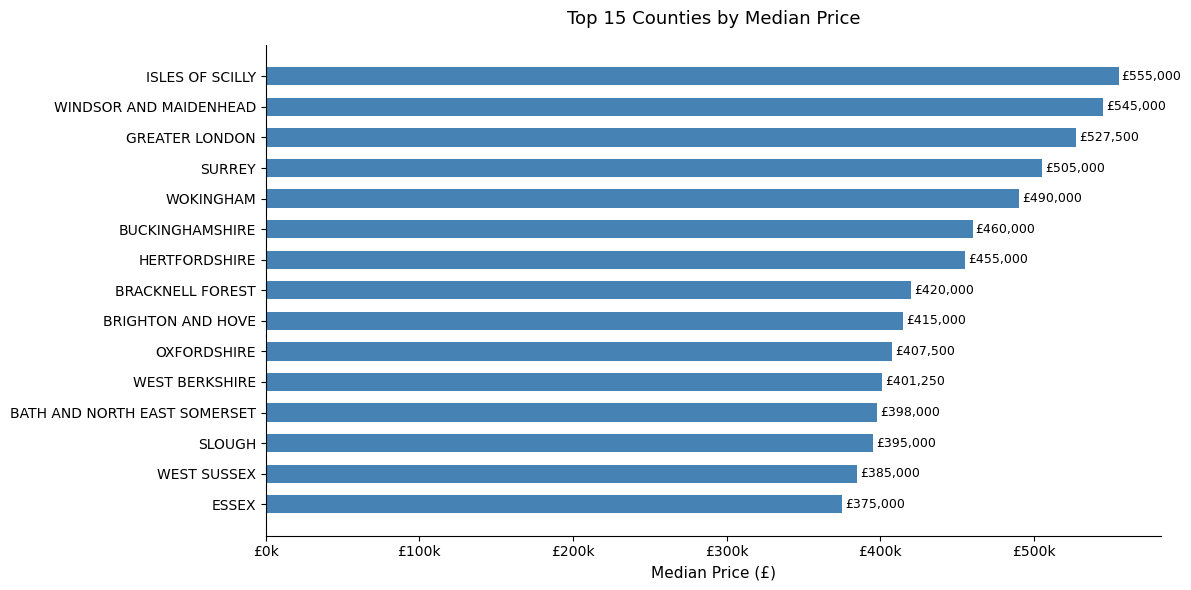

In [9]:
# Chart 4: Top 15 counties by median price
median_county = df.groupby('county')['price'].median().sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(median_county.index[::-1], median_county.values[::-1], color='steelblue', height=0.6)
for bar, val in zip(bars, median_county.values[::-1]):
    ax.text(val + 2000, bar.get_y() + bar.get_height()/2,
            f'£{val:,.0f}', va='center', fontsize=9)
ax.set_title('Top 15 Counties by Median Price', fontsize=13, pad=15)
ax.set_xlabel('Median Price (£)', fontsize=11)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x/1000:.0f}k'))
plt.tight_layout()
plt.savefig('chart4_top_counties.png', dpi=150)
plt.show()

## 6. Phase 1 Summary

In this phase we:
- ✅ Loaded the Land Registry dataset
- ✅ Cleaned the data (removed outliers and non-standard transactions)
- ✅ Analysed the price distribution
- ✅ Visualised prices by property type and geography

**Next — Phase 2:** Add external features (interest rates, inflation) and prepare the ML dataset.

In [10]:
df.to_csv('dataset_clean.csv', index=False)
print(f'Clean dataset saved: {len(df):,} rows')
print('Ready for Phase 2!')

Clean dataset saved: 739,435 rows
Ready for Phase 2!
